<span style = "font-family: Verdana; font-size: 20px">

#### **Feature Engineering**
</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import RFE
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("../data/modified/viz_pokemon.csv", keep_default_na = False)
combats_df = pd.read_csv('../data/raw_data/combats.csv')
combats_df = combats_df.drop_duplicates().reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    int64  
 1   Name                800 non-null    object 
 2   Type1               800 non-null    object 
 3   Type2               800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

Dummify cột `Type1` và `Type2`

In [3]:
type1dum = pd.get_dummies(df['Type1'], prefix='Type', dtype=int)
type2dum = pd.get_dummies(df['Type2'], prefix='Type', dtype=int)

dummies_total = type1dum.add(type2dum, fill_value=0)
df = pd.concat([df, dummies_total], axis=1)
df = df.drop(['Type1', 'Type2'], axis=1)

Chuyển `LevelingRate` thành các giá trị số tương ứng để sử dụng trong mô hình ML.

[Nguồn tham khảo](https://bulbapedia.bulbagarden.net/wiki/Experience)


In [4]:
df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_18408\1293140977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)


In [5]:
def create_intrinsic_metrics(df):
    # --- Alpha Strike (Sức Tấn Công Tối Ưu) ---
    df['Alpha_Strike'] = df[['Attack', 'SpecialAttack']].max(axis=1)

    # --- Sweeper Rating (Chỉ Số Quét Team) ---
    df['Sweeper_Rating'] = (df['Speed'] * df['Alpha_Strike']) / 1000

    # --- Glass Cannon Index (Chỉ Số "Máu Giấy") ---
    df['Glass_Cannon_Index'] = df['Alpha_Strike'] / (df['Defense'] + df['SpecialDefense'] + 1)

    # --- Type Vulnerability (Tổng Mức Độ Bị Khắc Chế) ---
    dmg_cols = [c for c in df.columns if c.startswith('DamageFrom')]
    df['Type_Vulnerability'] = df[dmg_cols].apply(lambda row: sum(x for x in row if x > 1.0), axis=1)
    
    cols_to_drop_safe = [col for col in df.columns if col.startswith('DamageFrom')]
    df.drop(columns=cols_to_drop_safe, inplace=True)

    return df

df = create_intrinsic_metrics(df)

**Xoá bỏ các cột chứa thông tin không giúp ích cho việc dự đoán kết quả chiến thắng của Pokemon. Các cột được loại bỏ liên quan đến các thông tin sơ bộ về Pokemon (chỉ số nội tại), thông tin có thể gây leakage**

In [6]:
drop_cols = [
    'PreevoName', 'FightsWon', 'TotalFights', 'WinPercentage', 'HasMega',
    'Weight', 'Height', 'GenderProbM', 'Category', 'EggCycles', 'BaseFriendship'
]
df.drop(columns = drop_cols, inplace = True)

In [7]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Name,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,CatchRate,LevelingRate,IsLegendary,IsMythical,EvoStage,TotalEvoStages,Ability1,Ability2,Type_,Type_Bug,Type_Dark,Type_Dragon,Type_Electric,Type_Fairy,Type_Fighting,Type_Fire,Type_Flying,Type_Ghost,Type_Grass,Type_Ground,Type_Ice,Type_Normal,Type_Poison,Type_Psychic,Type_Rock,Type_Steel,Type_Water,Alpha_Strike,Sweeper_Rating,Glass_Cannon_Index,Type_Vulnerability
0,1,Bulbasaur,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,45,1059860,0,0,1,3,Overgrow,None,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,65.0,2.925,0.565217,8.0
1,2,Ivysaur,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,45,1059860,0,0,2,3,Overgrow,None,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,80.0,4.800,0.555556,8.0
2,3,Venusaur,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,45,1059860,0,0,3,3,Overgrow,None,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,100.0,8.000,0.543478,8.0
3,4,Mega Venusaur,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,45,1059860,0,0,3,3,Thick Fat,None,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,122.0,9.760,0.500000,4.0
4,5,Charmander,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,45,1059860,0,0,1,3,Blaze,None,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,60.0,3.900,0.638298,6.0


**Merge dữ liệu từ hai tập Pokemon và Combats.csv để có bộ dữ liệu đầy đủ thông tin về dự đoán kết quả trận đấu**

In [8]:
stats_p1 = df.add_suffix('_P1')
stats_p2 = df.add_suffix('_P2')

# Merge cho Pokemon thứ nhất (First_pokemon)
final_df = pd.merge(
    combats_df,
    stats_p1,
    left_on='First_pokemon', 
    right_on='ID_P1',
    how='inner'
)

# Merge cho Pokemon thứ hai (Second_pokemon)
final_df = pd.merge(
    final_df,
    stats_p2,
    left_on='Second_pokemon', 
    right_on='ID_P2',
    how='inner'
)

# Tạo biến mục tiêu (P1 thắng = 1)
final_df['P1_Win'] = (final_df['Winner'] == final_df['First_pokemon']).astype(int)

final_df = final_df.drop(columns=['ID_P1', 'ID_P2', 'Winner', 'First_pokemon', 'Second_pokemon', 'Name_P1', 'Name_P2'])

In [9]:
final_df.shape

(48048, 81)

In [10]:
final_df.head()

,HiddenAbility_P1,Generation_P1,Hp_P1,Attack_P1,Defense_P1,SpecialAttack_P1,SpecialDefense_P1,Speed_P1,TotalStats_P1,CatchRate_P1,LevelingRate_P1,IsLegendary_P1,IsMythical_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,Type__P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,HiddenAbility_P2,Generation_P2,Hp_P2,Attack_P2,Defense_P2,SpecialAttack_P2,SpecialDefense_P2,Speed_P2,TotalStats_P2,CatchRate_P2,LevelingRate_P2,IsLegendary_P2,IsMythical_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,Type__P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,P1_Win
0,Sand Veil,2,50.0,64.0,50.0,45.0,50.0,41.0,300.0,45,1250000,0,0,1,3,Guts,None,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,2.624,0.633663,16.0,Pickpocket,3,70.0,70.0,40.0,60.0,40.0,60.0,340.0,120,1059860,0,0,2,3,Chlorophyll,Early Bird,0.0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,4.200,0.864198,16.0,0
1,None,5,91.0,90.0,72.0,90.0,129.0,108.0,580.0,3,1250000,1,0,1,1,Justified,None,0.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,9.720,0.445545,14.0,None,5,91.0,129.0,90.0,72.0,90.0,108.0,580.0,3,1250000,1,0,1,1,Justified,None,0.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,13.932,0.712707,14.0,0
2,Super Luck,2,55.0,40.0,85.0,80.0,105.0,40.0,405.0,75,800000,0,0,2,3,Hustle,Serene Grace,0.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,3.200,0.418848,10.0,Analytic,5,75.0,75.0,75.0,125.0,95.0,40.0,485.0,90,1000000,0,0,2,2,Telepathy,Synchronize,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,125.0,5.000,0.730994,6.0,0
3,Weak Armor,2,40.0,40.0,40.0,70.0,40.0,20.0,250.0,190,1000000,0,0,1,2,Magma Armor,Flame Body,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,70.0,1.400,0.864198,6.0,Mold Breaker,5,77.0,120.0,90.0,60.0,90.0,48.0,485.0,45,1000000,0,0,1,1,Rough Skin,Sheer Force,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,5.760,0.662983,6.0,0
4,Weak Armor,1,70.0,60.0,125.0,115.0,70.0,55.0,495.0,45,1000000,0,0,2,2,Swift Swim,Shell Armor,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,6.325,0.586735,10.0,Contrary,2,20.0,10.0,230.0,10.0,230.0,5.0,505.0,190,1059860,0,0,1,1,Sturdy,Gluttony,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,0.050,0.021692,6.0,1


### **Feature Engineering tạo các biến tương quan giữa Pokemon thứ nhất và thứ hai**

In [11]:
def create_feature(df):
    # Tấn công Vật lý vs Phòng thủ Vật lý (Physical Matchup)
    df['Phys_Advantage_P1'] = df['Attack_P1'] / (df['Defense_P2']+ 0.1)
    df['Phys_Advantage_P2'] = df['Attack_P2'] / (df['Defense_P1']+ 0.1)

    # Tấn công Đặc biệt vs Phòng thủ Đặc biệt (Special Matchup)
    df['Spec_Advantage_P1'] = df['SpecialAttack_P1'] / (df['SpecialDefense_P2'] + 0.1)
    df['Spec_Advantage_P2'] = df['SpecialAttack_P2'] / (df['SpecialDefense_P1'] + 0.1)

    # Alpha Strike: Khả năng dồn dame nhanh
    df['Alpha_Diff'] = df['Alpha_Strike_P1'] - df['Alpha_Strike_P2']

    df['Special_Power_P1'] = df['SpecialAttack_P1'] * df['Speed_P1']

    df['Log_Att_Def_Diff'] = np.log(df['Attack_P1'] + 1) - np.log(df['Defense_P2'] + 1)

    return df

In [12]:
# SPEED-BASED FEATURES =========================================

def add_speed_features(df):
    df['Speed_Difference'] = df['Speed_P1'] - df['Speed_P2']
    df['Speed_Ratio'] = df['Speed_P1'] / (df['Speed_P2'] + 1)
    
    df['Is_P1_Faster'] = (df['Speed_P1'] > df['Speed_P2']).astype(int)
    
    df['Speed_Tie'] = ((df['Speed_Ratio'] > 0.95) & (df['Speed_Ratio'] < 1.05)).astype(int)
    
    return df

In [13]:
# DEFENSIVE CAPABILITIES ==========================================

def add_defensive_features(df):
    df['P1_Physical_Bulk'] = df['Hp_P1'] * df['Defense_P1']
    df['P2_Physical_Bulk'] = df['Hp_P2'] * df['Defense_P2']
    
    df['P1_Special_Bulk'] = df['Hp_P1'] * df['SpecialDefense_P1']
    df['P2_Special_Bulk'] = df['Hp_P2'] * df['SpecialDefense_P2']
    
    return df

In [14]:
def diff_features(df):    
    stats_cols = [
        'Hp', 'Defense', 'SpecialAttack', 'TotalStats',
        'SpecialDefense', 'Attack'
    ]

    for col in stats_cols:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']

        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)

    special_flags = ['IsLegendary', 'IsMythical']
    for col in special_flags:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']
        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)
    
    return df

In [15]:
def engineer_all_features(df):
    df = create_feature(df)
    df = add_speed_features(df)
    df = add_defensive_features(df)
    df = diff_features(df)
    
    return df

pokemon_df = engineer_all_features(final_df)

In [16]:
pd.set_option('display.max_columns', None)
pokemon_df.head()

,HiddenAbility_P1,Generation_P1,Speed_P1,CatchRate_P1,LevelingRate_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,Type__P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,HiddenAbility_P2,Generation_P2,Speed_P2,CatchRate_P2,LevelingRate_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,Type__P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,P1_Win,Phys_Advantage_P1,Phys_Advantage_P2,Spec_Advantage_P1,Spec_Advantage_P2,Alpha_Diff,Special_Power_P1,Log_Att_Def_Diff,Speed_Difference,Speed_Ratio,Is_P1_Faster,Speed_Tie,P1_Physical_Bulk,P2_Physical_Bulk,P1_Special_Bulk,P2_Special_Bulk,Diff_Hp,Diff_Defense,Diff_SpecialAttack,Diff_TotalStats,Diff_SpecialDefense,Diff_Attack,Diff_IsLegendary,Diff_IsMythical
0,Sand Veil,2,41.0,45,1250000,1,3,Guts,None,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,2.624,0.633663,16.0,Pickpocket,3,60.0,120,1059860,2,3,Chlorophyll,Early Bird,0.0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,4.200,0.864198,16.0,0,1.596010,1.397206,1.122195,1.197605,-6.0,1845.0,0.460815,-19.0,0.672131,0,0,2500.0,2800.0,2500.0,2800.0,-20.0,10.0,-15.0,-40.0,10.0,-6.0,0,0
1,None,5,108.0,3,1250000,1,1,Justified,None,0.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,9.720,0.445545,14.0,None,5,108.0,3,1250000,1,1,Justified,None,0.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,13.932,0.712707,14.0,0,0.998890,1.789182,0.998890,0.557707,-39.0,9720.0,0.000000,0.0,0.990826,0,1,6552.0,8190.0,11739.0,8190.0,0.0,-18.0,18.0,0.0,39.0,-39.0,0,0
2,Super Luck,2,40.0,75,800000,2,3,Hustle,Serene Grace,0.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,3.200,0.418848,10.0,Analytic,5,40.0,90,1000000,2,2,Telepathy,Synchronize,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,125.0,5.000,0.730994,6.0,0,0.532623,0.881316,0.841220,1.189343,-45.0,3200.0,-0.617161,0.0,0.975610,0,1,4675.0,5625.0,5775.0,7125.0,-20.0,10.0,-45.0,-80.0,10.0,-35.0,0,0
3,Weak Armor,2,20.0,190,1000000,1,2,Magma Armor,Flame Body,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,70.0,1.400,0.864198,6.0,Mold Breaker,5,48.0,45,1000000,1,1,Rough Skin,Sheer Force,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,5.760,0.662983,6.0,0,0.443951,2.992519,0.776915,1.496259,-50.0,1400.0,-0.797287,-28.0,0.408163,0,0,1600.0,6930.0,1600.0,6930.0,-37.0,-50.0,10.0,-235.0,-50.0,-80.0,0,0
4,Weak Armor,1,55.0,45,1000000,2,2,Swift Swim,Shell Armor,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,6.325,0.586735,10.0,Contrary,2,5.0,190,1059860,1,1,Sturdy,Gluttony,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,0.050,0.021692,6.0,1,0.260756,0.079936,0.499783,0.142653,105.0,6325.0,-1.331544,50.0,9.166667,1,0,8750.0,4600.0,4900.0,4600.0,50.0,-105.0,105.0,-10.0,-160.0,50.0,0,0


In [17]:
pokemon_df.drop(columns=['HiddenAbility_P1', 'HiddenAbility_P2', 'Ability1_P1', 'Ability1_P2', 'Ability2_P1', 'Ability2_P2'], inplace = True)

In [18]:
X = pokemon_df.drop(columns=['P1_Win'])
y = pokemon_df['P1_Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [19]:
print("Shape of X train: ", {X_train.shape})

Shape of X train:  {(36036, 81)}


**KIỂM TRA CORRELATION**

In [20]:
def get_high_correlations(data, threshold=0.9):
    # Calculate correlation matrix
    corr_matrix = data.corr().abs()
    
    # Select upper triangle of correlation matrix (to avoid duplicates like A-B and B-A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    high_corr_pairs = []
    for column in upper.columns:
        for index in upper.index:
            # Check correlation value against threshold
            if upper.loc[index, column] > threshold:
                high_corr_pairs.append((index, column, upper.loc[index, column]))
    
    # Sort pairs by correlation strength (descending)
    return sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)

# --- SELECT NUMERIC FEATURES ONLY ---
# Select all numeric columns from X_train to avoid errors with object/string columns
features_to_check = X_train.select_dtypes(include=[np.number])

# Run the check function
high_corrs = get_high_correlations(features_to_check, threshold=0.9)

# Print results
print(f"Total features checked: {features_to_check.shape[1]}")
print(f"Pairs with correlation > 0.9 ({len(high_corrs)} pairs):")
print("-" * 50)
for pair in high_corrs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.4f}")

Total features checked: 81
Pairs with correlation > 0.9 (0 pairs):
--------------------------------------------------


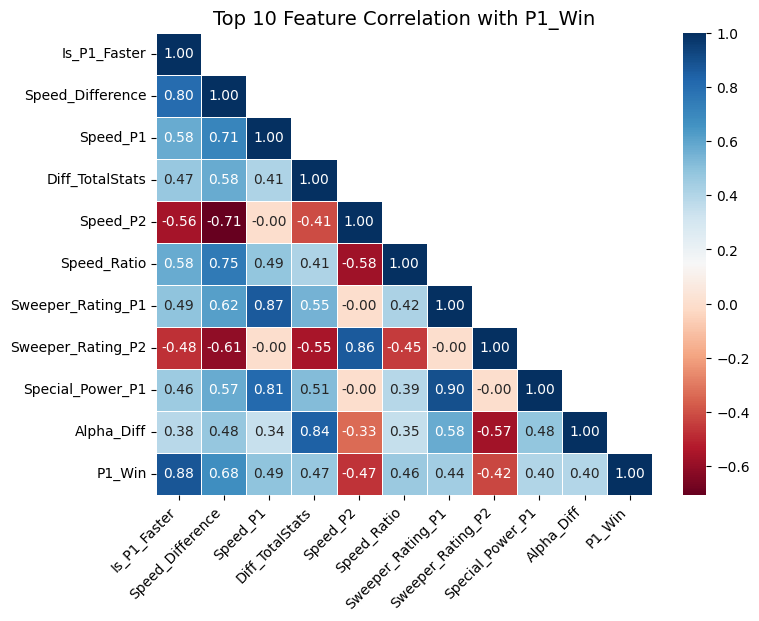

In [21]:
y_train_df = y_train.to_frame(name='P1_Win')
combined_df = pd.concat([X_train.select_dtypes(include=[np.number]), y_train_df], axis=1)

corr_matrix = combined_df.corr()

target_corr = corr_matrix['P1_Win'].sort_values(ascending=False, key=abs)
top_features = target_corr.index[1:11].tolist() 

corr_top = combined_df[top_features + ['P1_Win']].corr()

mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_top,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu',
    linewidths=.5
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Feature Correlation with P1_Win', fontsize=14)
plt.show()

## **TRAINING MODEL**

**KIỂM TRA VIF**

In [22]:
def calculate_vif(X_data):
    X_numeric = X_data.select_dtypes(include=[np.number])
    X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)
    scaler = StandardScaler()
    X_scaled_array = scaler.fit_transform(X_numeric)
    X_scaled_df = pd.DataFrame(X_scaled_array, columns=X_numeric.columns)
    
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_scaled_df.columns
    
    vif_df["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) 
                     for i in range(X_scaled_df.shape[1])]
    return vif_df.sort_values(by="VIF", ascending=False)

vif_full_result = calculate_vif(X_train)


print("Top 10 variables with the highest VIF")
print(vif_full_result.head(20))

Top 10 variables with the highest VIF
             Feature           VIF
9     Type_Dragon_P1  9.053005e+08
13      Type_Fire_P1  4.244213e+08
12  Type_Fighting_P1  4.118482e+08
19    Type_Normal_P1  3.799813e+08
10  Type_Electric_P1  3.635416e+08
18       Type_Ice_P1  1.311597e+08
11     Type_Fairy_P1  1.199762e+08
20    Type_Poison_P1  9.055947e+07
21   Type_Psychic_P1  7.393338e+07
15     Type_Ghost_P1  7.059068e+07
8       Type_Dark_P1  6.819311e+07
23     Type_Steel_P1  4.866487e+07
16     Type_Grass_P1  2.192754e+07
17    Type_Ground_P1  1.931728e+07
24     Type_Water_P1  1.259339e+07
65  Speed_Difference  9.468842e+06
22      Type_Rock_P1  7.489321e+06
51      Type_Rock_P2  7.276312e+06
41  Type_Fighting_P2  6.884324e+06
52     Type_Steel_P2  6.470531e+06


In [23]:
X_curr = X_train.select_dtypes(include=[np.number]).copy()

X_curr = X_curr.replace([np.inf, -np.inf], np.nan).fillna(0)

max_vif_threshold = 10 
keep_processing = True

count = 0
while keep_processing:
    count += 1
    scaler_temp = StandardScaler()
    X_scaled_temp = pd.DataFrame(scaler_temp.fit_transform(X_curr), columns=X_curr.columns)
    
    vif_df = calculate_vif(X_scaled_temp)
    
    max_vif = vif_df.iloc[0]["VIF"]
    worst_feature = vif_df.iloc[0]["Feature"]
    if max_vif > max_vif_threshold:
        if max_vif == float('inf'):
             print(f"Iter {count}: -> Removing {worst_feature} (Perfect Multicollinearity - VIF = inf)")
        else:
             print(f"Iter {count}: -> Removing {worst_feature} (VIF = {max_vif:.2f})")
        
        X_curr = X_curr.drop(columns=[worst_feature])
    else:
        print(f"Finished! All remaining {len(X_curr.columns)} features have VIF < {max_vif_threshold}")
        keep_processing = False

print("-" * 30)
print("Final feature list:")
print(X_curr.columns.tolist())

final_cols = X_curr.columns.tolist()

Iter 1: -> Removing Type_Dark_P1 (VIF = 2012737428.77)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iter 2: -> Removing Speed_Difference (Perfect Multicollinearity - VIF = inf)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iter 3: -> Removing Type_Fairy_P2 (Perfect Multicollinearity - VIF = inf)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iter 4: -> Removing Diff_Defense (Perfect Multicollinearity - VIF = inf)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iter 5: -> Removing Alpha_Strike_P1 (Perfect Multicollinearity - VIF = inf)
Iter 6: -> Removing Diff_TotalStats (VIF = 173.59)
Iter 7: -> Removing Sweeper_Rating_P1 (VIF = 40.47)
Iter 8: -> Removing Sweeper_Rating_P2 (VIF = 28.76)
Iter 9: -> Removing Alpha_Diff (VIF = 17.64)
Iter 10: -> Removing P2_Special_Bulk (VIF = 12.47)
Iter 11: -> Removing Diff_SpecialAttack (VIF = 11.44)
Finished! All remaining 70 features have VIF < 10
------------------------------
Final feature list:
['Generation_P1', 'Speed_P1', 'CatchRate_P1', 'LevelingRate_P1', 'EvoStage_P1', 'TotalEvoStages_P1', 'Type__P1', 'Type_Bug_P1', 'Type_Dragon_P1', 'Type_Electric_P1', 'Type_Fairy_P1', 'Type_Fighting_P1', 'Type_Fire_P1', 'Type_Flying_P1', 'Type_Ghost_P1', 'Type_Grass_P1', 'Type_Ground_P1', 'Type_Ice_P1', 'Type_Normal_P1', 'Type_Poison_P1', 'Type_Psychic_P1', 'Type_Rock_P1', 'Type_Steel_P1', 'Type_Water_P1', 'Glass_Cannon_Index_P1', 'Type_Vulnerability_P1', 'Generation_P2', 'Speed_P2', 'CatchRate_P2', 'LevelingRate_

In [44]:
X_train_vif = X_train[final_cols]
X_test_vif = X_test[final_cols]

scaler = StandardScaler()
X_train_vif_scaled = scaler.fit_transform(X_train_vif)

estimator = LogisticRegression(solver='liblinear', max_iter=2000)
rfe = RFE(estimator, n_features_to_select=25, step=1)
rfe = rfe.fit(X_train_vif_scaled, y_train)

selected_features_mask = rfe.support_
selected_cols = np.array(final_cols)[selected_features_mask]

print(f"Select {len(selected_cols)} features:")
print(selected_cols)

final_cols = selected_cols.tolist()

Select 25 features:
['Speed_P1' 'Type__P1' 'Type_Dragon_P1' 'Type_Fighting_P1' 'Type_Ghost_P1'
 'Type_Poison_P1' 'Speed_P2' 'Type_Dark_P2' 'Type_Dragon_P2'
 'Type_Flying_P2' 'Type_Ghost_P2' 'Type_Normal_P2' 'Type_Steel_P2'
 'Glass_Cannon_Index_P2' 'Phys_Advantage_P2' 'Spec_Advantage_P1'
 'Special_Power_P1' 'Log_Att_Def_Diff' 'Speed_Ratio' 'Is_P1_Faster'
 'Speed_Tie' 'P1_Physical_Bulk' 'P2_Physical_Bulk' 'Diff_Hp' 'Diff_Attack']


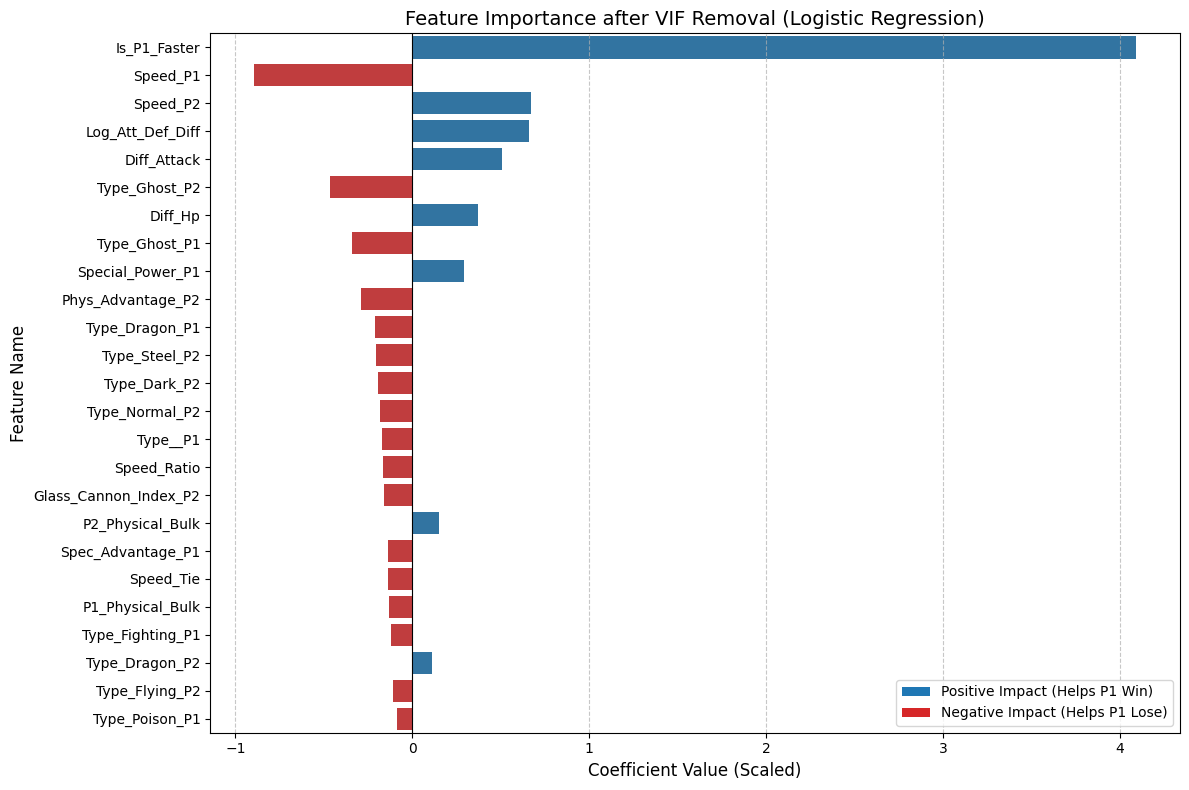

In [ ]:
coeffs = rfe.estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': final_cols,
    'Importance': coeffs
})

importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(12, 8))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in importance_df['Importance']]

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette=colors,
    hue='Feature', 
    legend=False
)

plt.title('Feature Importance after VIF Removal (Logistic Regression)', fontsize=14)
plt.xlabel('Coefficient Value (Scaled)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Positive Impact (Helps P1 Win)'),
                   Patch(facecolor='#d62728', label='Negative Impact (Helps P1 Lose)')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

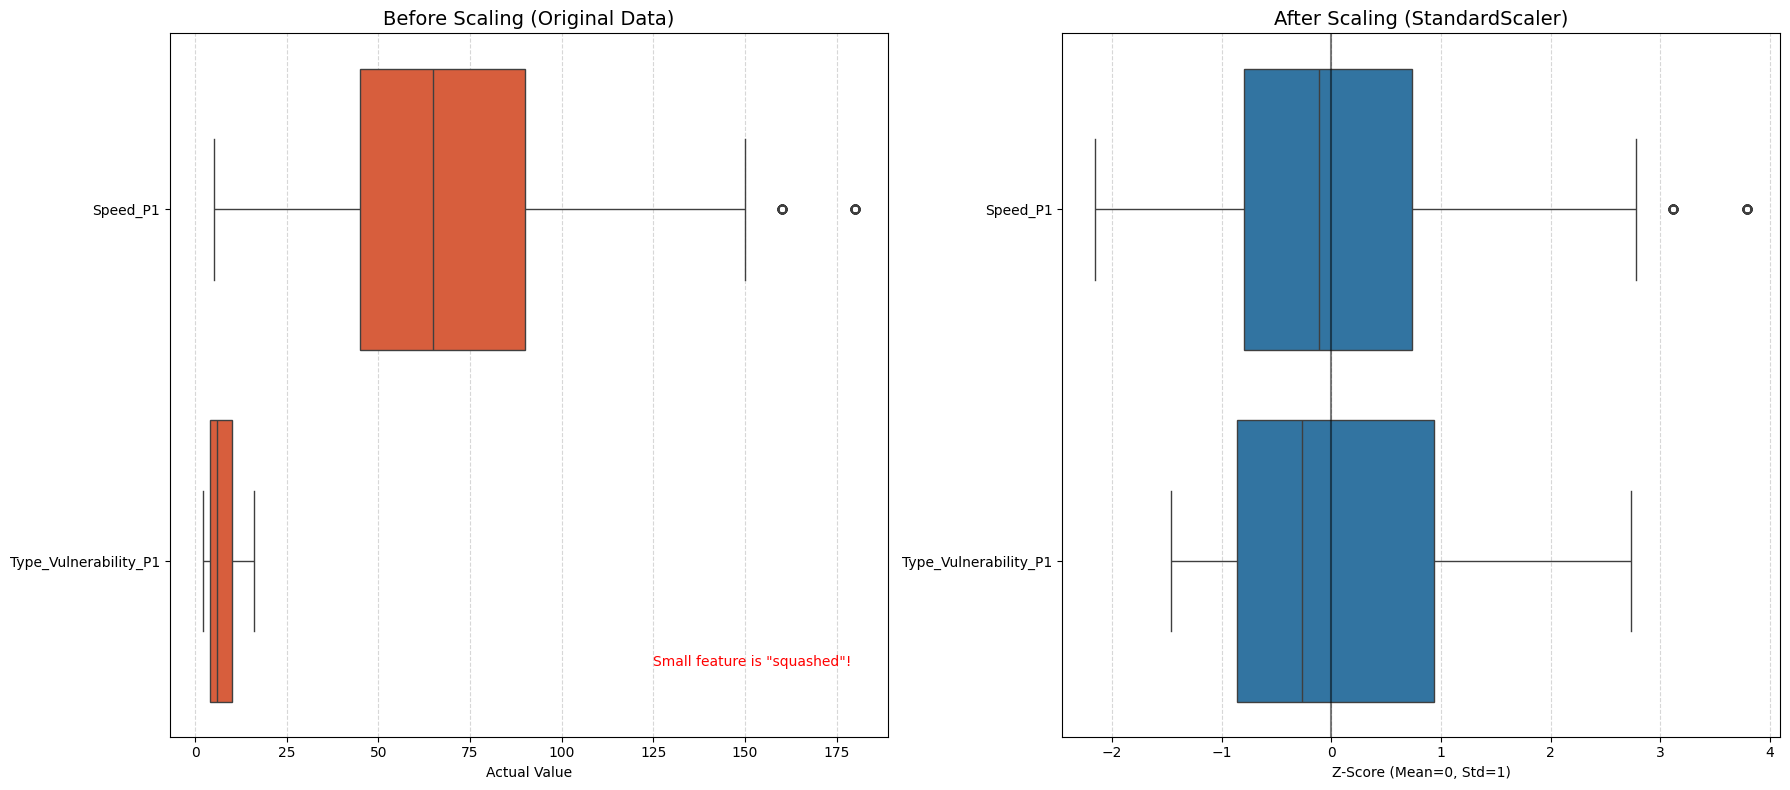

In [ ]:
scaler = StandardScaler()
X_numeric = X_train.select_dtypes(include=[np.number])
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), 
                              columns=X_numeric.columns, 
                              index=X_numeric.index)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

cols_to_plot = ['Speed_P1', 'Type_Vulnerability_P1']

valid_cols = [c for c in cols_to_plot if c in X_train.columns]

if not valid_cols:
    print("Requested columns not found in X_train.")
else:
    sns.boxplot(data=X_train[valid_cols], ax=axes[0], orient='h', color="#f05024")
    axes[0].set_title('Before Scaling (Original Data)', fontsize=14, color='black')
    axes[0].set_xlabel('Actual Value')
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)
    
    axes[0].text(0.95, 0.1, 'Small feature is "squashed"!', 
                 transform=axes[0].transAxes, ha='right', color='red')

    sns.boxplot(data=X_train_scaled[valid_cols], ax=axes[1], orient='h', color="#1f77b4")
    axes[1].set_title('After Scaling (StandardScaler)', fontsize=14, color='black')
    axes[1].set_xlabel('Z-Score (Mean=0, Std=1)')
    
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5) 
    axes[1].grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [33]:
top_features = selected_cols.tolist()  

poly_log_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear')) 
])

poly_log_model.fit(X_train[top_features], y_train)

train_acc = accuracy_score(y_train, poly_log_model.predict(X_train[top_features]))
test_acc = accuracy_score(y_test, poly_log_model.predict(X_test[top_features]))

print(f"Logistic Regression: Train={train_acc:.4f}, Test={test_acc:.4f}")

Logistic Regression: Train=0.9547, Test=0.9527


In [43]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix
import time

def evaluate_model(model, X_test, y_test, model_name="Model"):
    # 1. Dự đoán nhãn và xác suất
    start_time = time.time()
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] 
    end_time = time.time()
    
    # 2. Tính các chỉ số
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    print(f"📊 EVALUATION {model_name.upper()}:")
    print(f"- Accuracy : {acc:.4f} ")
    print(f"- Log Loss : {ll:.4f} ")
    print(f"- ROC-AUC  : {auc:.4f} ")
    print(f"- F1-Score : {f1:.4f}")
    print(f"- Predict Time: {end_time - start_time:.4f}s")
    print("-" * 30)

evaluate_model(poly_log_model, X_test[top_features], y_test, "Prepared Data Model")

📊 EVALUATION PREPARED DATA MODEL:
- Accuracy : 0.9527 
- Log Loss : 0.1451 
- ROC-AUC  : 0.9848 
- F1-Score : 0.9500
- Predict Time: 0.1354s
------------------------------
